# Simulation 3 — analysis (Binomial size sweep)

Mirror of [simulation 1's analysis](../simulation_1/analysis.ipynb) for **Binomial(10)**
responses: Procrustes error across the $p\times n$ sweep, tail risk, bias/variance,
and timing — `zqe` vs `gllvm` (`family="binomial", Ntrials=10`).

In [1]:
%load_ext autoreload
%autoreload 2
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
HERE = os.path.dirname(os.path.abspath("__file__")) if "__file__" in globals() else os.getcwd()
if not os.path.exists(os.path.join(HERE, "sweep.py")):
    HERE = os.path.join(os.getcwd(), "simulations", "simulation_3")
sys.path.insert(0, HERE)
import sweep
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
METHODS = ["zqe", "gllvm"]
MCOLOR  = {"zqe": "#1f77b4", "gllvm": "#d62728"}

df = sweep.load_results()
P_VALS = sorted(df.p.unique()); N_VALS = sorted(df.n.unique())
print(f"settings: p={P_VALS}  n={N_VALS}  (Binomial N={sweep.BINOM_TRIALS})")
print(f"reps/setting: {df.groupby(['p','n']).rep.nunique().min()}"
      f"-{df.groupby(['p','n']).rep.nunique().max()}")

settings: p=[np.int64(10), np.int64(20), np.int64(50), np.int64(100)]  n=[np.int64(20), np.int64(100), np.int64(500)]  (Binomial N=10)
reps/setting: 20-20


## Per-fit summary & failures

In [2]:
fits = (df[df.method != "true"].drop_duplicates(["p", "n", "rep", "method"])
        [["p", "n", "rep", "method", "failed", "time_sec", "procrustes"]]
        .reset_index(drop=True))
print("failures:", int(fits.failed.sum()), "/", len(fits))
ok = fits[fits.failed == 0.0].copy()
ok.groupby(["p", "n", "method"]).size().unstack("method")

failures: 0 / 480


method   gllvm  zqe
p   n              
10  20      20   20
    100     20   20
    500     20   20
20  20      20   20
    100     20   20
    500     20   20
50  20      20   20
    100     20   20
    500     20   20
100 20      20   20
    100     20   20
    500     20   20

## 1 · Procrustes error across the sweep

Boxplots over reps; one panel per $p$, the two methods side by side at each $n$.

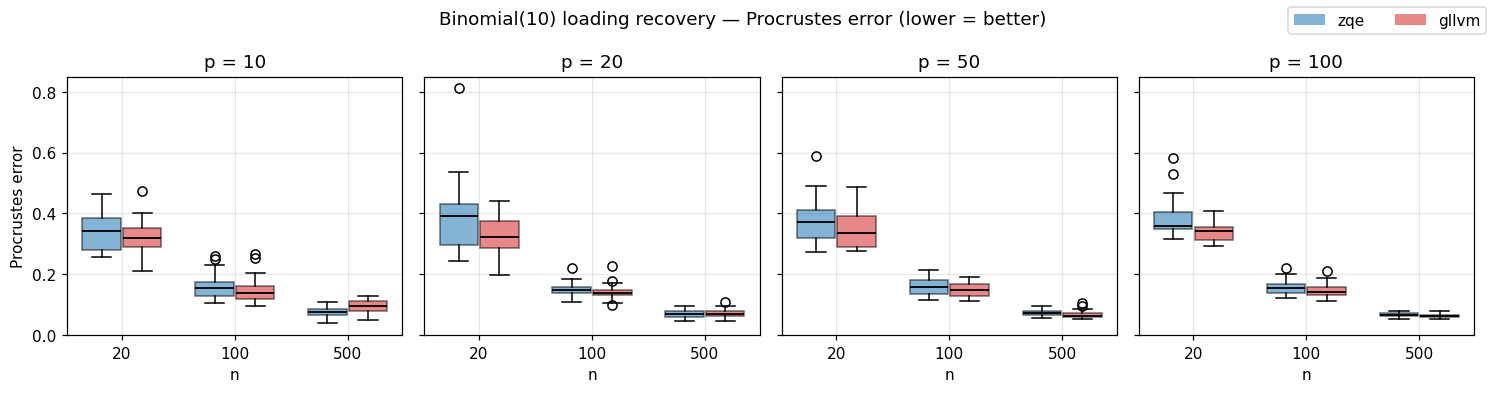

In [3]:
def grouped_box(ax, sub, value, p):
    width, offs = 0.34, {"zqe": -0.18, "gllvm": +0.18}
    xticks = np.arange(len(N_VALS))
    for m in METHODS:
        data = [sub[(sub.n == n) & (sub.method == m)][value].dropna().values for n in N_VALS]
        bp = ax.boxplot(data, positions=xticks + offs[m], widths=width,
                        patch_artist=True, manage_ticks=False, showfliers=True)
        for box in bp["boxes"]: box.set(facecolor=MCOLOR[m], alpha=0.55)
        for med in bp["medians"]: med.set(color="black", lw=1.2)
    ax.set_xticks(xticks); ax.set_xticklabels(N_VALS)
    ax.set_title(f"p = {p}"); ax.set_xlabel("n")

fig, axes = plt.subplots(1, len(P_VALS), figsize=(3.4 * len(P_VALS), 3.6), sharey=True)
for ax, p in zip(np.atleast_1d(axes), P_VALS):
    grouped_box(ax, ok[ok.p == p], "procrustes", p)
axes[0].set_ylabel("Procrustes error")
handles = [plt.Rectangle((0, 0), 1, 1, fc=MCOLOR[m], alpha=0.55) for m in METHODS]
fig.legend(handles, METHODS, loc="upper right", ncol=2)
fig.suptitle("Binomial(10) loading recovery — Procrustes error (lower = better)")
fig.tight_layout(); plt.show()

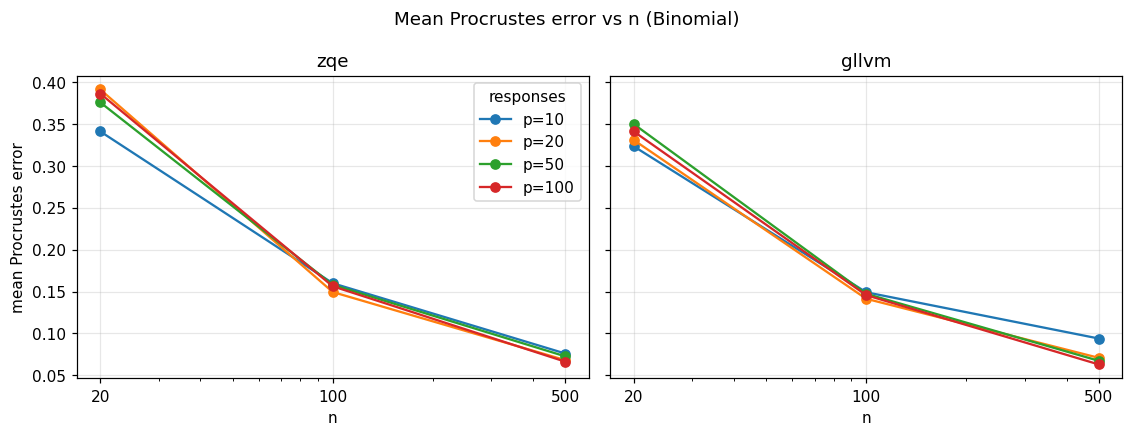

In [4]:
fig, axes = plt.subplots(1, len(METHODS), figsize=(5.2 * len(METHODS), 4), sharey=True)
mean_p = ok.groupby(["method", "p", "n"]).procrustes.mean().reset_index()
for ax, m in zip(np.atleast_1d(axes), METHODS):
    for p in P_VALS:
        s = mean_p[(mean_p.method == m) & (mean_p.p == p)].sort_values("n")
        ax.plot(s.n, s.procrustes, "o-", label=f"p={p}")
    ax.set_xscale("log"); ax.set_xticks(N_VALS); ax.set_xticklabels(N_VALS)
    ax.set_title(m); ax.set_xlabel("n")
axes[0].set_ylabel("mean Procrustes error"); axes[0].legend(title="responses")
fig.suptitle("Mean Procrustes error vs n (Binomial)"); fig.tight_layout(); plt.show()

## 1b · Tail risk & worst-case

median           p90         worst           std       
method   gllvm    zqe  gllvm    zqe  gllvm    zqe  gllvm    zqe
p   n                                                          
10  20   0.320  0.343  0.382  0.416  0.475  0.465  0.059  0.060
    100  0.137  0.154  0.208  0.231  0.265  0.258  0.047  0.045
    500  0.096  0.074  0.122  0.100  0.129  0.109  0.022  0.018
20  20   0.322  0.391  0.422  0.479  0.441  0.811  0.062  0.127
    100  0.138  0.147  0.171  0.182  0.228  0.219  0.029  0.025
    500  0.070  0.068  0.089  0.083  0.109  0.095  0.016  0.013
50  20   0.334  0.373  0.447  0.445  0.487  0.588  0.067  0.076
    100  0.147  0.159  0.182  0.188  0.191  0.213  0.025  0.026
    500  0.063  0.071  0.087  0.086  0.104  0.094  0.014  0.011
100 20   0.340  0.359  0.393  0.473  0.407  0.581  0.034  0.069
    100  0.140  0.155  0.184  0.183  0.209  0.221  0.026  0.026
    500  0.063  0.066  0.070  0.077  0.078  0.078  0.007  0.007

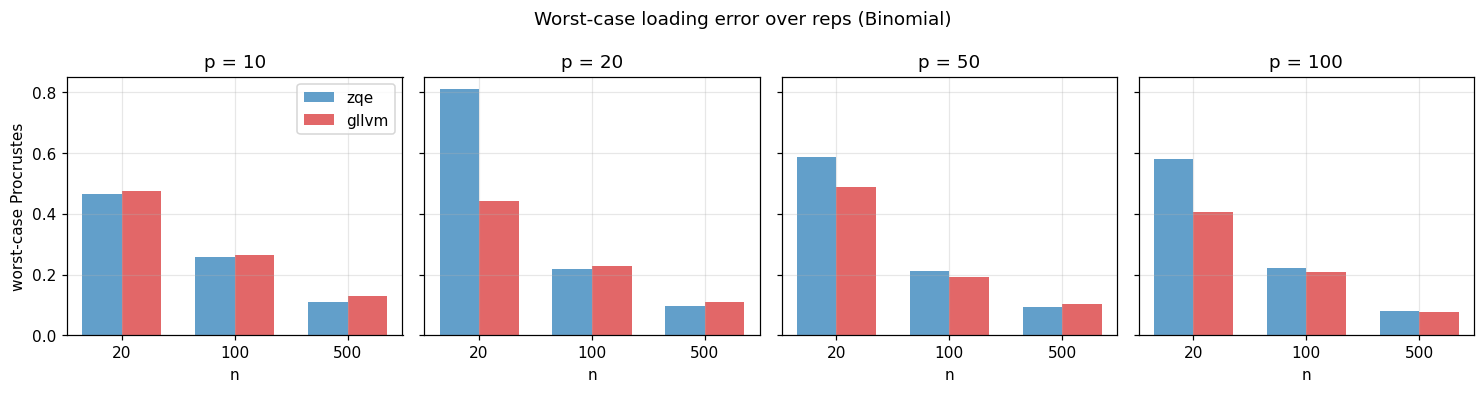

In [5]:
tail = (ok.groupby(["p", "n", "method"]).procrustes
        .agg(median="median", p90=lambda s: s.quantile(0.90),
             worst="max", std="std").round(3))
display(tail.unstack("method"))

fig, axes = plt.subplots(1, len(P_VALS), figsize=(3.4 * len(P_VALS), 3.6), sharey=True)
worst = ok.groupby(["p", "n", "method"]).procrustes.max().reset_index()
for ax, p in zip(np.atleast_1d(axes), P_VALS):
    xt = np.arange(len(N_VALS))
    for k, m in enumerate(METHODS):
        s = worst[(worst.p == p) & (worst.method == m)].set_index("n").reindex(N_VALS)
        ax.bar(xt + (k - 0.5) * 0.35, s.procrustes.values, width=0.35,
               color=MCOLOR[m], alpha=0.7, label=m)
    ax.set_xticks(xt); ax.set_xticklabels(N_VALS)
    ax.set_title(f"p = {p}"); ax.set_xlabel("n")
axes[0].set_ylabel("worst-case Procrustes"); axes[0].legend()
fig.suptitle("Worst-case loading error over reps (Binomial)")
fig.tight_layout(); plt.show()

## 2 · Bias & variance

In [6]:
truth = (df[df.method == "true"][["p","n","rep","param","i","j","value"]]
         .rename(columns={"value": "true"}))
est = df[df.method.isin(METHODS) & (df.failed == 0.0)]
res = est.merge(truth, on=["p","n","rep","param","i","j"], how="left")
res["resid"] = res["value"] - res["true"]
bv = (res[res.param == "W"].groupby(["p","n","method"])
      .agg(bias=("resid","mean"), std=("resid","std"),
           rmse=("resid", lambda r: float(np.sqrt(np.mean(r**2))))).round(4).reset_index())
display(bv.pivot_table(index=["p","n"], columns="method", values=["bias","std","rmse"]))

bias            rmse             std        
method    gllvm     zqe   gllvm     zqe   gllvm     zqe
p   n                                                  
10  20   0.0105  0.0147  0.2199  0.2313  0.2199  0.2311
    100  0.0016  0.0018  0.1006  0.1101  0.1007  0.1102
    500 -0.0003 -0.0004  0.0657  0.0511  0.0658  0.0511
20  20   0.0025  0.0111  0.2411  0.3067  0.2412  0.3067
    100  0.0031  0.0020  0.1012  0.1071  0.1012  0.1072
    500  0.0025  0.0034  0.0520  0.0491  0.0520  0.0490
50  20   0.0187  0.0145  0.2522  0.2707  0.2515  0.2704
    100  0.0035  0.0025  0.1050  0.1127  0.1049  0.1127
    500  0.0001 -0.0003  0.0485  0.0520  0.0485  0.0520
100 20  -0.0053 -0.0063  0.2406  0.2752  0.2405  0.2752
    100  0.0002 -0.0001  0.1035  0.1110  0.1035  0.1110
    500  0.0004  0.0001  0.0445  0.0467  0.0445  0.0467

## 3 · Fit time

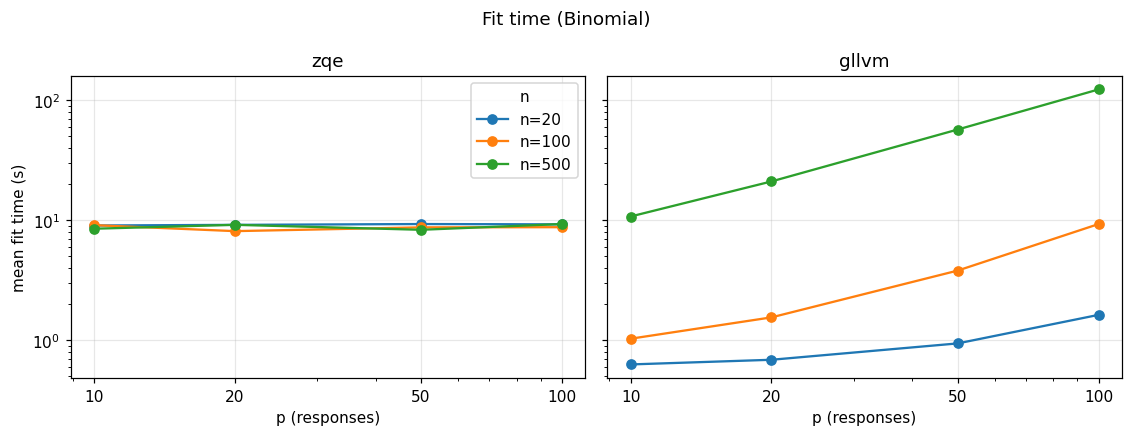

In [7]:
fig, axes = plt.subplots(1, len(METHODS), figsize=(5.2 * len(METHODS), 4), sharey=True)
mean_t = ok.groupby(["method", "p", "n"]).time_sec.mean().reset_index()
for ax, m in zip(np.atleast_1d(axes), METHODS):
    for n in N_VALS:
        s = mean_t[(mean_t.method == m) & (mean_t.n == n)].sort_values("p")
        ax.plot(s.p, s.time_sec, "o-", label=f"n={n}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(P_VALS); ax.set_xticklabels(P_VALS)
    ax.set_title(m); ax.set_xlabel("p (responses)")
axes[0].set_ylabel("mean fit time (s)"); axes[0].legend(title="n")
fig.suptitle("Fit time (Binomial)"); fig.tight_layout(); plt.show()

## Takeaways

The Binomial twin of simulation 1, now identifiable across the grid (N=10 trials
removes the Bernoulli separation pathology). Read alongside the Poisson sweep:
where the MLE is asymptotically efficient it edges the clean median, but ZQE's
variance / worst-case / speed advantages persist. Compact head-to-head below.

In [8]:
head = (ok.groupby(["p", "n", "method"])
        .agg(procrustes=("procrustes", "mean"), time_s=("time_sec", "mean"))
        .round(3).reset_index()
        .pivot_table(index=["p", "n"], columns="method", values=["procrustes", "time_s"]))
head

procrustes          time_s       
method       gllvm    zqe    gllvm    zqe
p   n                                    
10  20       0.323  0.341    0.629  9.035
    100      0.149  0.160    1.031  9.102
    500      0.094  0.076   10.738  8.494
20  20       0.331  0.391    0.688  9.149
    100      0.141  0.149    1.552  8.111
    500      0.071  0.068   21.043  9.154
50  20       0.350  0.376    0.942  9.294
    100      0.147  0.158    3.808  8.720
    500      0.067  0.073   56.940  8.324
100 20       0.341  0.386    1.628  9.236
    100      0.146  0.156    9.292  8.749
    500      0.063  0.066  122.847  9.295